#  Chargement et Exploration des Données - Dataset GMR-PL (Google Maps Reviews — Polish)

Chargement et inspection du jeu de données Google Maps Reviews pour la détection de faux avis.

## Importations

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

## Configuration des Chemins

In [16]:
# Configuration des chemins
BASE_DIR = Path().absolute().parent
DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

print(f"📁 Répertoire de base : {BASE_DIR}")
print(f"📁 Répertoire des données brutes : {DATA_RAW_DIR}")

📁 Répertoire de base : c:\Users\aaras\Desktop\Projet_5MEM\review-guardian
📁 Répertoire des données brutes : c:\Users\aaras\Desktop\Projet_5MEM\review-guardian\data\raw


## Chargement des Données

In [19]:
# Charger les avis
reviews_path = DATA_RAW_DIR / "reviews.csv"
print(f"Chargement des avis depuis : {reviews_path}")
reviews = pd.read_csv(reviews_path)
print(f"✅ {len(reviews):,} avis chargés")

Chargement des avis depuis : c:\Users\aaras\Desktop\Projet_5MEM\review-guardian\data\raw\reviews.csv
✅ 17,979 avis chargés


In [20]:
# Charger les comptes
accounts_path = DATA_RAW_DIR / "accounts.csv"
print(f"Chargement des comptes depuis : {accounts_path}")
accounts = pd.read_csv(accounts_path)
print(f"✅ {len(accounts):,} comptes chargés")

Chargement des comptes depuis : c:\Users\aaras\Desktop\Projet_5MEM\review-guardian\data\raw\accounts.csv
✅ 605 comptes chargés


## Aperçu du Jeu de Données

In [22]:
print("=" * 80)
print("Dataset des avis")
print("=" * 80)
print(f"Dimensions : {reviews.shape}")
print(f"Colonnes : {list(reviews.columns)}")
print("\n3 premières lignes :")
reviews.head(3)

Dataset des avis
Dimensions : (17979, 17)
Colonnes : ['_id', 'account_id', 'approximate_localization.lat', 'approximate_localization.lon', 'censored_text', 'cluster', 'content', 'content_not_full', 'content_translated', 'date', 'is_real', 'localization_missing', 'not_in_poland', 'photos_urls', 'rating', 'response_content', 'type_of_object']

3 premières lignes :


,_id,account_id,approximate_localization.lat,approximate_localization.lon,censored_text,cluster,content,content_not_full,content_translated,date,is_real,localization_missing,not_in_poland,photos_urls,rating,response_content,type_of_object
0,63e2e0d98b0803f03c00c02f,63e546a08f7e73edc5913876,53.3,15.9,False,Shops,Ok,False,False,2023-01-10T20:17:09.732Z,True,False,False,[],4,NaN,Dyskont spożywczy
1,63f2bcae8047cae56c427a1d,63e546a08f7e73edc5913876,53.6,15.6,False,Other services,Ok,False,False,2023-01-10T20:17:09.513Z,True,False,False,[],4,NaN,Magazyn
2,63f2bdc8ec2561ca0a25eb27,63e546a08f7e73edc5913876,53.6,15.7,False,Leisure,NaN,False,False,2022-11-11T20:17:09.942Z,True,False,False,[],5,NaN,Stadnina koni


In [23]:
print("=" * 80)
print("Dataset des comptes")
print("=" * 80)
print(f"Dimensions : {accounts.shape}")
print(f"Colonnes : {list(accounts.columns)}")
print("\n3 premières lignes :")
accounts.head(3)

Dataset des comptes
Dimensions : (605, 7)
Colonnes : ['_id', 'is_deleted', 'is_private', 'is_real', 'local_guide_level', 'name_score', 'number_of_reviews']

3 premières lignes :


,_id,is_deleted,is_private,is_real,local_guide_level,name_score,number_of_reviews
0,63e546a08f7e73edc5913876,False,False,True,5.0,744861,78.0
1,63e546e28f7e73edc59138c4,False,False,True,0.0,0,6.0
2,63e546f98f7e73edc59138cb,False,False,True,8.0,813520,532.0


## Types de Données

In [24]:
print("TYPES DE DONNEES DES AVIS :")
print(reviews.dtypes)

TYPES DE DONNEES DES AVIS :
_id                              object
account_id                       object
approximate_localization.lat    float64
approximate_localization.lon    float64
censored_text                      bool
cluster                          object
content                          object
content_not_full                   bool
content_translated                 bool
date                             object
is_real                            bool
localization_missing               bool
not_in_poland                      bool
photos_urls                      object
rating                            int64
response_content                 object
type_of_object                   object
dtype: object


In [25]:
print("TYPES DE DONNEES DES COMPTES :")
print(accounts.dtypes)

TYPES DE DONNEES DES COMPTES :
_id                   object
is_deleted              bool
is_private              bool
is_real                 bool
local_guide_level    float64
name_score             int64
number_of_reviews    float64
dtype: object


## Analyse des Valeurs Manquantes

In [26]:
print("VALEURS MANQUANTES DES AVIS :")
print("=" * 60)
missing_reviews = reviews.isnull().sum()
missing_reviews_pct = (reviews.isnull().sum() / len(reviews)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_reviews,
    'Percentage': missing_reviews_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) == 0:
    print("✅ Aucune valeur manquante !")
else:
    display(missing_df)

VALEURS MANQUANTES DES AVIS :


,Missing Count,Percentage
response_content,17323,96.351299
content,4628,25.741142
photos_urls,2451,13.632571
approximate_localization.lat,117,0.650759
approximate_localization.lon,117,0.650759


In [27]:
print("VALEURS MANQUANTES DES COMPTES :")
print("=" * 60)
missing_accounts = accounts.isnull().sum()
missing_accounts_pct = (accounts.isnull().sum() / len(accounts)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_accounts,
    'Percentage': missing_accounts_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) == 0:
    print("✅ Aucune valeur manquante !")
else:
    display(missing_df)

VALEURS MANQUANTES DES COMPTES :


,Missing Count,Percentage
number_of_reviews,161,26.611570
local_guide_level,132,21.818182


## Distribution des Étiquettes (Faux vs Vrai)

DISTRIBUTION DES LABEL DES AVIS :
Vrai (True):  15,543 (86.45%)
Faux (False): 2,436 (13.55%)

 Imbalance ratio : 6.38:1


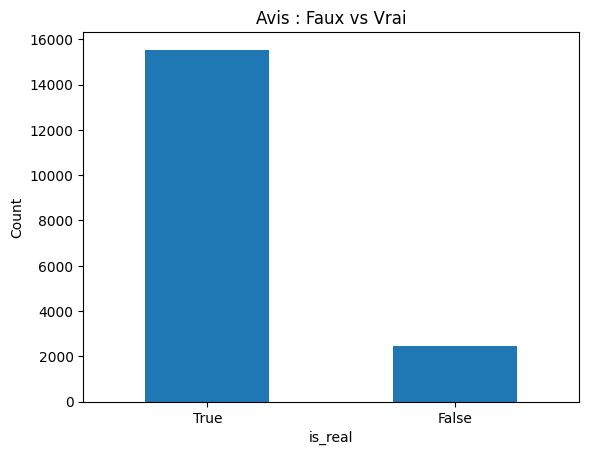

In [28]:
print("DISTRIBUTION DES LABEL DES AVIS :")
print("=" * 60)
reviews_dist = reviews['is_real'].value_counts()
reviews_pct = reviews['is_real'].value_counts(normalize=True) * 100

print(f"Vrai (True):  {reviews_dist[True]:,} ({reviews_pct[True]:.2f}%)")
print(f"Faux (False): {reviews_dist[False]:,} ({reviews_pct[False]:.2f}%)")
print(f"\n Imbalance ratio : {reviews_dist[True]/reviews_dist[False]:.2f}:1")

# Visualisation
reviews['is_real'].value_counts().plot(kind='bar', title='Avis : Faux vs Vrai')
import matplotlib.pyplot as plt
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

DISTRIBUTION DES LABEL DES COMPTES :
Vrai (True):  286 (47.27%)
Faux (False): 319 (52.73%)

Imbalance ratio : 0.90:1


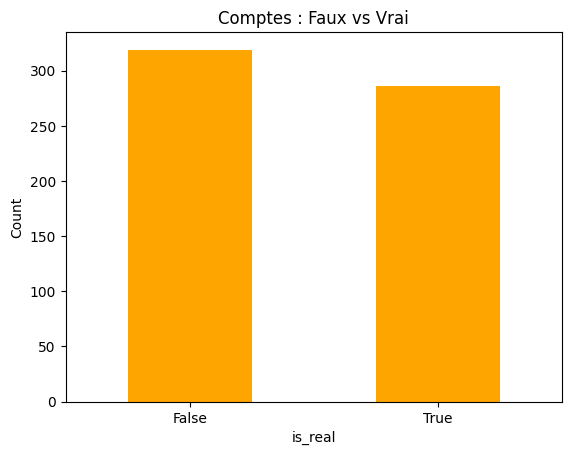

In [29]:
print("DISTRIBUTION DES LABEL DES COMPTES :")
print("=" * 60)
accounts_dist = accounts['is_real'].value_counts()
accounts_pct = accounts['is_real'].value_counts(normalize=True) * 100

print(f"Vrai (True):  {accounts_dist[True]:,} ({accounts_pct[True]:.2f}%)")
print(f"Faux (False): {accounts_dist[False]:,} ({accounts_pct[False]:.2f}%)")
print(f"\nImbalance ratio : {accounts_dist[True]/accounts_dist[False]:.2f}:1")

# Visualisation
accounts['is_real'].value_counts().plot(kind='bar', title='Comptes : Faux vs Vrai', color='orange')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Statistiques

In [30]:
print("STATISTIQUES DES AVIS :")
print("=" * 80)
reviews.describe()

STATISTIQUES DES AVIS :


,approximate_localization.lat,approximate_localization.lon,rating
count,17862.000000,17862.000000,17979.000000
mean,51.276111,17.349356,4.562156
std,4.138958,12.357536,0.861769
min,-38.600000,-158.100000,1.000000
25%,50.500000,16.700000,4.000000
50%,51.800000,18.700000,5.000000
75%,53.000000,20.900000,5.000000
max,68.300000,177.700000,5.000000


In [31]:
print("STATISTIQUES DES COMPTES :")
print("=" * 80)
accounts.describe()

STATISTIQUES DES COMPTES :


,local_guide_level,name_score,number_of_reviews
count,473.000000,6.050000e+02,444.000000
mean,2.000000,2.591015e+05,45.427928
std,2.592362,2.630585e+05,92.742060
min,0.000000,0.000000e+00,1.000000
25%,0.000000,1.387900e+04,5.000000
50%,0.000000,2.003720e+05,14.000000
75%,5.000000,3.985370e+05,37.000000
max,8.000000,1.347560e+06,825.000000


## Résumé

- Avis : 17 979 entrées avec 17 features
- Comptes : 605 entrées avec 7 features
- Déséquilibre de classes détecté dans le jeu de données des avis
- Plusieurs valeurs manquantes identifiées